# Mini Flappy Bird - World Model
## Phase 1: Environment Setup & Unsupervised Rollout Collection
Architecture reference: Ha & Schmidhuber (World Models, 2018)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

### 1. Lightweight Minimalist Flappy Bird Engine

In [2]:
class MiniFlappy:
    """Minimalist Flappy Bird environment with a 32x32 RGB canvas."""
    
    # 1. Canvas Dimensions
    SIZE = 32  # 32x32 resolution gives 3,072 float32 values per frame
    
    # 2. Color Palette (normalized float32 values [0.0, 1.0])
    BG_COLOR   = np.array([0.08, 0.08, 0.16], dtype=np.float32)  # Dark navy sky
    BIRD_COLOR = np.array([1.00, 1.00, 0.00], dtype=np.float32)  # High-contrast bright yellow
    PIPE_COLOR = np.array([0.10, 0.80, 0.25], dtype=np.float32)  # Vibrant green
    
    # 3. Bird Geometry
    BIRD_X = 8      # Bird is pinned horizontally at column 8
    BIRD_SIZE = 2   # 2x2 pixel footprint
    
    # 4. Pipe Geometry
    PIPE_WIDTH = 3
    GAP_SIZE = 9 

    # 5. Physics Constants
    GRAVITY = 0.3
    FLAP_STRENGTH = -1.2
    MAX_SPEED = 3.0

    def __init__(self, seed=None):
        self.rng = np.random.default_rng(seed)
        self.reset()
        
    def reset(self):
        self.t = 0
        self.bird_y = float(self.SIZE // 2)
        self.bird_vel = 0.0
        self.pipe_x = float(self.SIZE - 1)
        max_gap_y = self.SIZE - 4 - self.GAP_SIZE
        self.gap_y = self.rng.integers(4, max_gap_y + 1)
        return self.observe()

    def _spawn_pipe(self):
        """Spawns a new pipe with a random vertical gap."""
        self.pipe_x = float(self.SIZE - 1)
        max_gap_y = self.SIZE - 4 - self.GAP_SIZE
        self.gap_y = self.rng.integers(4, max_gap_y + 1)
        
    def update_pipe(self):
        """Scroll the pipe leftward by 1 pixel per time step."""
        self.pipe_x -= 1.0
        if self.pipe_x + self.PIPE_WIDTH <= 0:
            self._spawn_pipe()

    def update_bird(self, action):
        """Applies flap impulse (action=1) or gravity (action=0) and updates position."""
        if action == 1:
            self.bird_vel = self.FLAP_STRENGTH
            
        self.bird_vel = float(np.clip(self.bird_vel + self.GRAVITY, -self.MAX_SPEED, self.MAX_SPEED))
        self.bird_y += self.bird_vel

        # Floor and ceiling boundaries
        max_y = float(self.SIZE - self.BIRD_SIZE)
        if self.bird_y < 0.0:
            self.bird_y = 0.0
            self.bird_vel = 0.0
        elif self.bird_y > max_y:
            self.bird_y = max_y
            self.bird_vel = 0.0

    def step(self, action):
        """
        Advances the world by 1 frame given an action (0=fall, 1=flap).
        Returns: (next_observation, done)
        """
        self.update_bird(action)
        self.update_pipe()
        self.t += 1
        done = self.t >= 100
        return self.observe(), done

    def observe(self):
        """Renders current state into a (32, 32, 3) float32 RGB image."""
        # 1. Empty background sky
        frame = np.full((self.SIZE, self.SIZE, 3), self.BG_COLOR, dtype=np.float32)
        
        # 2. Render pipes
        px = int(round(self.pipe_x))
        x_start = max(0, px)
        x_end = min(self.SIZE, px + self.PIPE_WIDTH)

        if x_start < x_end:
            # Top pipe
            frame[0:self.gap_y, x_start:x_end] = self.PIPE_COLOR
            # Bottom pipe
            frame[self.gap_y + self.GAP_SIZE:self.SIZE, x_start:x_end] = self.PIPE_COLOR

        # 3. Render bird
        yi = int(round(self.bird_y))
        xi = int(self.BIRD_X)
        
        y_min = max(0, yi)
        y_max = min(self.SIZE, yi + self.BIRD_SIZE)
        x_min = max(0, xi)
        x_max = min(self.SIZE, xi + self.BIRD_SIZE)
        
        frame[y_min:y_max, x_min:x_max] = self.BIRD_COLOR
        return frame

### 2. Collect Unsupervised Rollouts (200 Episodes x 100 Steps)

In [3]:
EPISODES = 200
T = 100
SIZE = 32
SEED = 42

env = MiniFlappy(seed=SEED)
rng = np.random.default_rng(SEED)

# Pre-allocate memory for frames and actions
frames = np.zeros((EPISODES, T, SIZE, SIZE, 3), dtype=np.float32)
actions = np.zeros((EPISODES, T), dtype=np.int64)

print(f"Recording {EPISODES} episodes of {T} steps each...")

for e in range(EPISODES):
    obs = env.reset()
    for t in range(T):
        # Random policy: flap ~18% of the time, fall ~82% of the time
        a = 1 if (rng.random() < 0.18) else 0
        
        frames[e, t] = obs
        actions[e, t] = a
        
        obs, done = env.step(a)

print("Collection completed!")
print(f"Frames shape: {frames.shape} | Memory: {frames.nbytes / (1024 * 1024):.1f} MB")
print(f"Actions shape: {actions.shape}")

Recording 200 episodes of 100 steps each...
Collection completed!
Frames shape: (200, 100, 32, 32, 3) | Memory: 234.4 MB
Actions shape: (200, 100)


### 3. Verify Rollouts (Inspect Consecutive Frames)

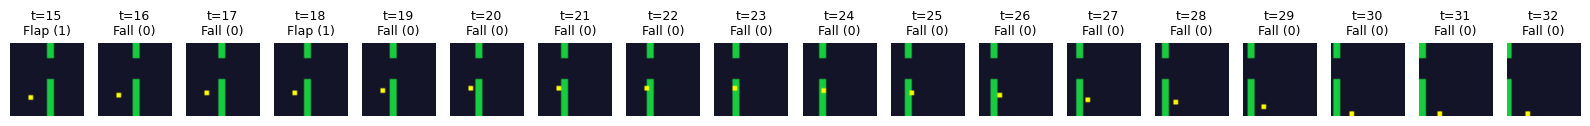

In [4]:
e_to_view = 10
start_step = 15
num_frames = 18

fig, axes = plt.subplots(1, num_frames, figsize=(16, 3))
for i in range(num_frames):
    t = start_step + i
    img = frames[e_to_view, t]
    act = actions[e_to_view, t]
    act_label = "Flap (1)" if act == 1 else "Fall (0)"
    
    axes[i].imshow(img)
    axes[i].set_title(f"t={t}\n{act_label}", fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 4. Prepare PyTorch Dataset for Vision Model (VAE)
Flatten (200 episodes, 100 steps) into 20,000 independent frames and convert to channel-first format: (N, C, H, W).

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert to torch tensor: (200, 100, 32, 32, 3) -> (20000, 32, 32, 3)
all_frames = torch.tensor(frames, dtype=torch.float32).reshape(-1, SIZE, SIZE, 3)
# Permute to PyTorch channel-first format: (N, H, W, C) -> (N, C, H, W)
all_frames = all_frames.permute(0, 3, 1, 2).contiguous()

print(f"Original NumPy shape: {frames.shape}")
print(f"PyTorch training tensor shape: {all_frames.shape} (N, C, H, W)")

Using device: cpu
Original NumPy shape: (200, 100, 32, 32, 3)
PyTorch training tensor shape: torch.Size([20000, 3, 32, 32]) (N, C, H, W)


--- 
## Phase 2: Vision Model (Variational Autoencoder)
Next step: Building the Encoder, Reparameterization Trick, Decoder, and Weighted Loss Function.

In [6]:
class VAE(nn.Module):
          def __init__(self,latent_dim = 32):
               super().__init__()

               """ we are initializing our work tool so that we do not have to initaliaing it again and agian 
               """



               ## encoder toolkit 
               self.conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)
               self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
               self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
          
          
               ## Linear projection toolkit
               self.fc_mu = nn.Linear(128*4*4, latent_dim)
               self.fc_logvar = nn.Linear(128*4*4, latent_dim)

               ## Deocder toolkit 

               self.fc_dec = nn.Linear(latent_dim,128*4*4)
               self.deconv1 = nn.ConvTranspose2d(128,64,kernel_size=4,stride=2,padding=1)
               self.deconv2 = nn.ConvTranspose2d(64,32,kernel_size=4,stride=2,padding=1)
               self.deconv3 = nn.ConvTranspose2d(32,3,kernel_size=4,stride=2,padding=1)



          

          




          
          
          def encode(self, x):
                    """
                    INPUT : (N,3,32,32)
                    OUTPUT : (mu, logvar)

                    Variable : N: no of photo phased / Batch_size [ N = 64 ] for our project
                    funtion : we are compressing the photos to different convolutional layer

                              [64,3,32,32]
                                   │
                                   ▼ 
                              [64,32,16,16]
                                   │
                                   ▼ 
                              [64,64,8,8]
                                   │
                                   ▼ 
                              [64,128,4,4]
                                   │
                                   ▼ 
                              [ mu,logvar]
                    
                    
                    
                    """
                    # Passing it through 3 convolutional layer

                    h = F.relu(self.conv1(x))
                    h = F.relu(self.conv2(h))
                    h = F.relu(self.conv3(h))

                    # flatening the [N,128,4,4] shape of 3D  into  1D flat vector
                    h_flat = h.view(h.size(0),-1)  # (N,2048)

                    ## 
                    mu = self.fc_mu(h_flat)            # pass through linear head

                    logvar = self.fc_logvar(h_flat)   # pass through linear head
                    return mu , logvar

          def reparameterize(self, mu,logvar):
                    """
                    INPUT : [mu , logvar]    
                    OUTPUT: z

                    Variable: 
                    function: CALCULATES (Z)
                    
                    
                    
                    
                    std = torch.exp(0.5 * logvar) # ---> log(sigma^2)
                    eps = random sample form normal distribution (0,1)

                    z = mu + std * eps

                    special case toruch has in built flag self.training of on during training and off during testing 



                    
                    
                    """

                    if self.training:

                         # calculating sigma = exp(0.5 * logvar)
                         std = torch.exp(0.5 * logvar)
                         # Sample random noises form normal dist ( 0,1)
                         eps = torch.randn_like(std)
                         return mu+std*eps
                    else:
                         return mu

          def decode(self,z):
               """ 
               INPUT : z
               OUTPUT : (N,3,32,32) // complete photo reconstructed


               Variable : z,N
               functions : reconstructed alomost the identical photo form latent variable (z )
                              [N,128,4,4]
                                   │
                                   ▼ 
                              [N,64,8,8]
                                   │
                                   ▼ 
                              [N,32,16,16]
                                   │
                                   ▼ 
                              [N,16,32,32]
                                   │
                                   ▼
                              (N,3,32,32)
               """

               h = self.fc_dec(z).view(z.size(0), 128, 4, 4)

               h=F.relu(self.deconv1(h))
               h=F.relu(self.deconv2(h))
               recon_x = torch.sigmoid(self.deconv3(h))
               return recon_x


          def forward(self,x):


                    """
                    
                         INPUT: takes all the forward founction 
                         1.  encode(x)
                         2.  decode(x)
                         3. reparameterazed(x)


                         Ouput : reonn_x,mu,logvar

                         fucntion : does all the forward pass of convalution by wraping all the three function in one single step 
                         and returns the [reonconstruction loss , mu , logvar ]

                    """


                    #encode image to distribution 

                    mu,logvar = self.encode(x)

                    # producing the lavent vecotr z

                    z = self.reparameterize(mu,logvar)

                    # reconstructing image from z
                    recon_x = self.decode(z)

                    return recon_x, mu , logvar




In [7]:
vae = VAE().to(device)
test_batch = all_frames[:64].to(device)


### Loss Component for - Reconstruction Loss + KL divergencr

In [8]:
def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    """
    recon_x: Reconstructed frame (N, 3, 32, 32)
    x:       Original ground truth frame (N, 3, 32, 32)
    mu:      Latent mean (N, 32)
    logvar:  Latent log-variance (N, 32)
    beta:    Weight on the KL divergence term



    
    """
    # 1. Weighted Reconstruction Loss
    weights = torch.ones_like(x)
    # Give 15x importance to the bird and pipes so the bird never disappears
    weights[x > 0.25] = 15.0
    
    recon_loss = torch.sum(weights * (recon_x - x) ** 2) / x.size(0)
    
    # 2. KL Divergence Loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


## Data Loader

In [9]:

# packaging the 20,000 frames into a pytorch dataset
dataset = TensorDataset(all_frames)

# Create the Dealer
loader = DataLoader(dataset, batch_size=64,shuffle=True)


vae = VAE(latent_dim = 32).to(device)

# Optimizers 
optimizer = torch.optim.Adam(vae.parameters(),lr=1e-3)

In [10]:
EPOCHS = 15
vae.train() # Put model in training mode (turns on noise in reparameterize)

print("Starting VAE training...")

for epoch in range(1, EPOCHS + 1):
    total_epoch_loss = 0.0
    total_recon_loss = 0.0
    total_kl_loss = 0.0
    
    for (batch,) in loader:
        batch = batch.to(device)
        
        # 1. Zero gradients
        optimizer.zero_grad()
        
        # 2. Forward pass
        recon, mu, logvar = vae(batch)
        
        # 3. Calculate loss
        loss, r_loss, k_loss = vae_loss_function(recon, batch, mu, logvar, beta=1.0)
        
        # 4. Backward pass
        loss.backward()
        
        # 5. Update weights
        optimizer.step()
        
        total_epoch_loss += loss.item() * batch.size(0)
        total_recon_loss += r_loss.item() * batch.size(0)
        total_kl_loss += k_loss.item() * batch.size(0)
        
    avg_loss = total_epoch_loss / len(all_frames)
    avg_recon = total_recon_loss / len(all_frames)
    avg_kl = total_kl_loss / len(all_frames)
    
    print(f"Epoch [{epoch:2d}/{EPOCHS}] | Total Loss: {avg_loss:.2f} | Recon Loss: {avg_recon:.2f} | KL Loss: {avg_kl:.4f}")

print("VAE Training Complete!")


Starting VAE training...


Epoch [ 1/15] | Total Loss: 148.30 | Recon Loss: 132.91 | KL Loss: 15.3892
Epoch [ 2/15] | Total Loss: 51.50 | Recon Loss: 33.08 | KL Loss: 18.4196
Epoch [ 3/15] | Total Loss: 40.00 | Recon Loss: 22.28 | KL Loss: 17.7109
Epoch [ 4/15] | Total Loss: 33.96 | Recon Loss: 16.56 | KL Loss: 17.3982
Epoch [ 5/15] | Total Loss: 30.24 | Recon Loss: 13.24 | KL Loss: 17.0009
Epoch [ 6/15] | Total Loss: 28.11 | Recon Loss: 11.46 | KL Loss: 16.6484
Epoch [ 7/15] | Total Loss: 26.66 | Recon Loss: 10.19 | KL Loss: 16.4679
Epoch [ 8/15] | Total Loss: 25.62 | Recon Loss: 9.33 | KL Loss: 16.2933
Epoch [ 9/15] | Total Loss: 24.49 | Recon Loss: 8.43 | KL Loss: 16.0656
Epoch [10/15] | Total Loss: 23.98 | Recon Loss: 7.98 | KL Loss: 16.0042
Epoch [11/15] | Total Loss: 22.93 | Recon Loss: 7.30 | KL Loss: 15.6259
Epoch [12/15] | Total Loss: 22.46 | Recon Loss: 6.91 | KL Loss: 15.5502
Epoch [13/15] | Total Loss: 21.79 | Recon Loss: 6.48 | KL Loss: 15.3107
Epoch [14/15] | Total Loss: 21.49 | Recon Loss: 6.28 | 

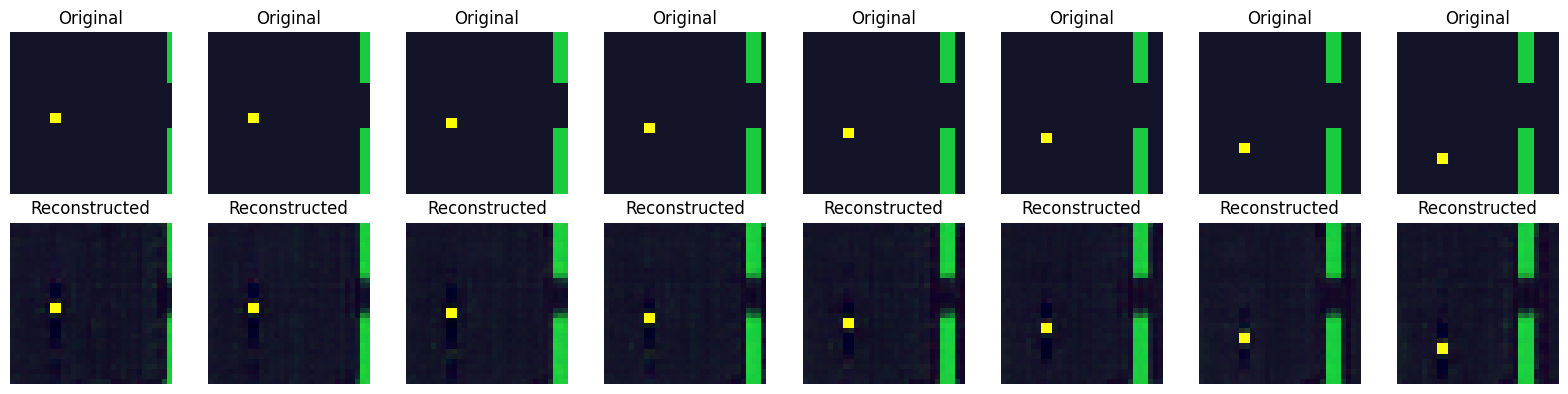

In [11]:
vae.eval() # Turn OFF training noise (use exact mean mu)

with torch.no_grad():
    sample_originals = all_frames[100:108].to(device)
    sample_recons, _, _ = vae(sample_originals)

# Convert back to (N, H, W, C) NumPy arrays for matplotlib
orig_imgs = sample_originals.permute(0, 2, 3, 1).cpu().numpy()
recon_imgs = sample_recons.permute(0, 2, 3, 1).cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(orig_imgs[i])
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    
    axes[1, i].imshow(recon_imgs[i])
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


In [12]:

LATENT_DIM = 32
# Now we are in evaluton  mode ( we turn off random noise)
vae.eval()


with torch.no_grad(): # (Turns off gradient memory to run fast)
          # pass all the photos through the encoder

          # Input : (20000,3,32,32)
          # Output : all_mu has shape (20000, 32)


          # it give mu , logvar we will ingore logvar (-)

          all_mu , _ = vae.encode(all_frames.to(device))

          # Re-organising the 20,000 frames back into 200 ep * 100 tims steps
          # Shape becoms : (200 ep , 100 steps, 32 latent numbers)
          latent_dataset = all_mu.view(EPISODES,T,LATENT_DIM).cpu()
          



In [13]:

# 2. Check shapes and memory
orig_mb = all_frames.element_size() * all_frames.nelement() / (1024 * 1024)
latent_mb = latent_dataset.element_size() * latent_dataset.nelement() / (1024 * 1024)
print(f"Original Pixel Dataset shape : {all_frames.shape} ({orig_mb:.1f} MB)")
print(f"Pre-encoded Latent Dataset  : {latent_dataset.shape} ({latent_mb:.2f} MB)")
print(f"Single time-step code shape  : {latent_dataset[0, 0].shape} (32 numbers)")


Original Pixel Dataset shape : torch.Size([20000, 3, 32, 32]) (234.4 MB)
Pre-encoded Latent Dataset  : torch.Size([200, 100, 32]) (2.44 MB)
Single time-step code shape  : torch.Size([32]) (32 numbers)


### Phase 3 : Adding memory unit (M)

### Creating the [latent , action ]

In [14]:
class MemoryModel(nn.Module):
    def __init__(self, latent_dim=32, action_dim=1, hidden_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        
        # Total input: 32 (latent) + 1 (action) = 33
        input_dim = latent_dim + action_dim
        
        # Worker 1: Recurrent Memory (GRU)
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        
        # Worker 2: Future Predictor Head
        self.fc = nn.Linear(in_features=hidden_dim, out_features=latent_dim)
        
    def step(self, z_t, a_t,h_t=None):
        """
        Runs ONE single clock tick.
        
        Inputs:
            z_t: (Batch, 32) -> current latent
            a_t: (Batch, 1)  -> current action
            h_t: (1, Batch, 128) -> previous memory (or None at t=0)
            
        Returns:
            z_hat_next: (Batch, 32) -> predicted next latent
            h_next:     (1, Batch, 128) -> updated memory for the next tick
        """
        # 1. Combine [z_t, a_t] -> Shape: (Batch, 33)
        x_t = torch.cat([z_t, a_t], dim=-1)
        
        # 2. Add sequence dimension of length 1 -> Shape: (Batch, 1, 33)
        x_t = x_t.unsqueeze(1)
        
        # 3. GRU updates memory: gru_out is (Batch, 1, 128), h_next is (1, Batch, 128)
        gru_out, h_next = self.gru(x_t, h_t)
        
        # 4. Predict next latent: (Batch, 1, 32) -> squeeze to (Batch, 32)
        z_hat_next = self.fc(gru_out).squeeze(1)


      
        
        return z_hat_next, h_next



    def loss(self, z_hat_next,z_target):

        """ 

            [ z_t, a_t, h] ---> { GRU } ---> ||(next state) - z_t+1|| ^ 2 ( MSE)
                                    |   
                                    |
                                    V
                                   [h+1]

        """

        loss = nn.MSELoss(self.z_hat_next,z_target)

        return loss








In [15]:
z_0 = latent_dataset[0,0:1,:]
a_0 = torch.tensor([[1.0]])
h_0 = None


In [16]:
model = MemoryModel()
z_hat_1,h_1 = model.step(z_0,a_0,h_t=None)

print("Predicted z_1 shape : " , z_hat_1.shape)
print("Updated memory h_1 shape : ", h_1.shape)


Predicted z_1 shape :  torch.Size([1, 32])
Updated memory h_1 shape :  torch.Size([1, 1, 128])


In [17]:
action_tensor = torch.tensor(actions,dtype=torch.float32).unsqueeze(-1)

In [20]:
## Glue  the data together 
dataset  = TensorDataset(latent_dataset, action_tensor)

# Create DataLoader (batch size = 32 episodes at a time, shuffled)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 

In [23]:

memory = MemoryModel().to(device)
critertion = nn.MSELoss()
optimizer = torch.optim.Adam(memory.parameters(),lr=1e-3)


EPOCHS  = 20 
print(" We are going to start training ")


for epoch in range(1,EPOCHS+1):


          epoch_loss = 0.0


          # loop over batches of episodes ( 32 episodes per batch )
          for batch_latents,batch_actions in loader:

                    batch_latents = batch_latents.to(device)
                    batch_actions  = batch_actions.to(device)


                    batch_loss = 0.0
                    optimizer.zero_grad()

                    h = None ## memory start blank at t = 0



                    # step through time from t= 0 to t = 99
                    for t in range(99):
                              z_t = batch_latents[:, t, :]
                              a_t = batch_actions[:, t, :]
                              z_target = batch_latents[:, t+1, :]
                              # update the memory and predict next state

                              z_hat_next,h = memory.step(z_t,a_t,h)

                              ## Accumulate MSE loss for this step

                              step_loss = critertion(z_hat_next,z_target)
                              batch_loss += step_loss
                    
                    # average loss
                    batch_loss = batch_loss/99


                    # backprapogate through time and update network

                    batch_loss.backward()

                    optimizer.step()

                    epoch_loss +=  batch_loss.item()


          avg_epoch_loss = epoch_loss/len(loader)

          print(f"Epoch [{epoch:2d}/{EPOCHS}] | Latent MSE Loss: {avg_epoch_loss:.6f}")



 We are going to start training 


Epoch [ 1/20] | Latent MSE Loss: 0.310158
Epoch [ 2/20] | Latent MSE Loss: 0.253057
Epoch [ 3/20] | Latent MSE Loss: 0.199781
Epoch [ 4/20] | Latent MSE Loss: 0.148112
Epoch [ 5/20] | Latent MSE Loss: 0.108964
Epoch [ 6/20] | Latent MSE Loss: 0.086301
Epoch [ 7/20] | Latent MSE Loss: 0.075437
Epoch [ 8/20] | Latent MSE Loss: 0.064239
Epoch [ 9/20] | Latent MSE Loss: 0.056698
Epoch [10/20] | Latent MSE Loss: 0.051916
Epoch [11/20] | Latent MSE Loss: 0.047887
Epoch [12/20] | Latent MSE Loss: 0.044768
Epoch [13/20] | Latent MSE Loss: 0.042494
Epoch [14/20] | Latent MSE Loss: 0.040193
Epoch [15/20] | Latent MSE Loss: 0.038666
Epoch [16/20] | Latent MSE Loss: 0.036943
Epoch [17/20] | Latent MSE Loss: 0.035496
Epoch [18/20] | Latent MSE Loss: 0.033941
Epoch [19/20] | Latent MSE Loss: 0.032995
Epoch [20/20] | Latent MSE Loss: 0.032597


### Validation step 

In [24]:
from numpy import shape
## Putting the model
vae.eval()
memory.eval()


# Pick episode 0

ep_latents = latent_dataset[0].to(device)
ep_actions = action_tensor[0].to(device)

shape(ep_latents)


torch.Size([100, 32])

In [30]:
# list to collect image for plotting 
real_imgs = []
pred_imgs = []


In [27]:
h = None

# warm up from 0-9
for t in range(10):
          # grab z_t and a_t at index t ( add batch dimension with .unsqeeze(0))

          z_t  = ep_latents[t].unsqueeze(0)
          a_t  = ep_actions[t].unsqueeze(0)

          # Update memory h ( ingore the prediction as of now)

          _,h = memory.step(z_t,a_t,h)

In [32]:
with torch.no_grad():
          for t in range(10,19):
                    z_t = ep_latents[t].unsqueeze(0)
                    a_t = ep_actions[t].unsqueeze(0)


                    # get the prediction z_hat_next and h_next 

                    z_hat_next,h = memory.step(z_t,a_t,h)


                    # adding it to the decoder to predict the real image pixal 
                    pred_frame = vae.decode(z_hat_next).squeeze(0).permute(1, 2, 0).cpu().numpy()
                    pred_imgs.append(pred_frame)

                    # Save the real next frame for comparison 
                    real_imgs.append(frames[0,t+1])



                    

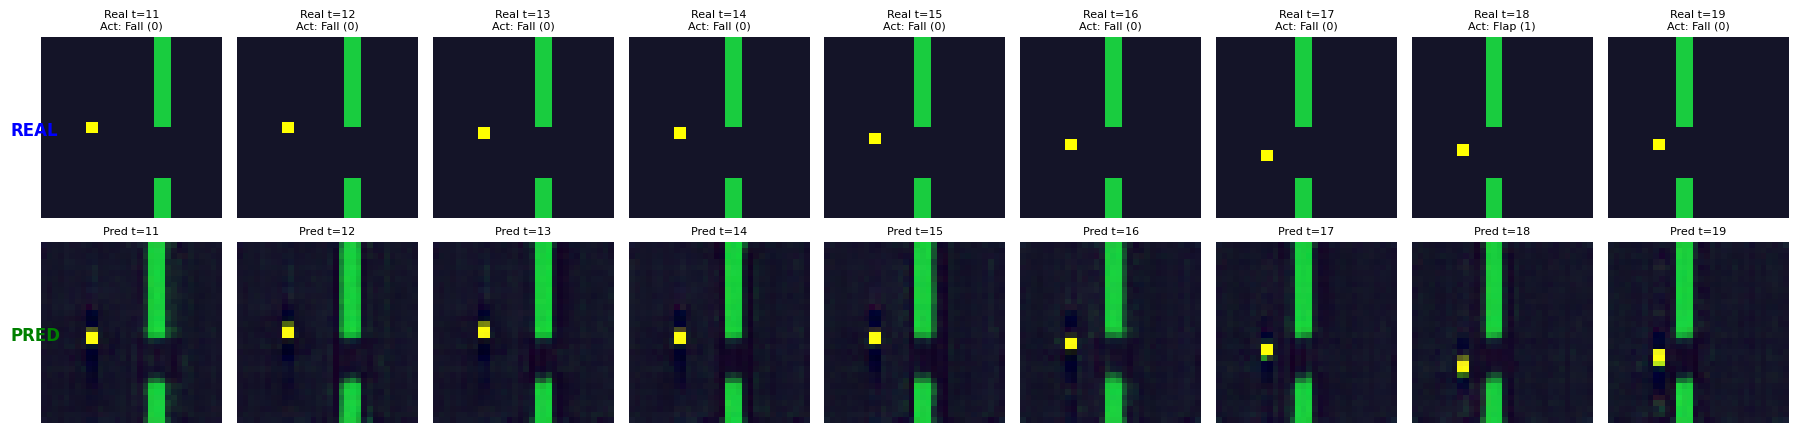

In [38]:
num_steps = len(pred_imgs)  # 9 frames
fig, axes = plt.subplots(2, num_steps, figsize=(18, 4.5))

for i in range(num_steps):
    t_target = 10 + i + 1   # Target time step (11 to 19)
    act = int(ep_actions[10 + i].item())
    act_name = "Flap (1)" if act == 1 else "Fall (0)"
    
    # 1. Top row: Real frame
    axes[0, i].imshow(real_imgs[i])
    axes[0, i].set_title(f"Real t={t_target}\nAct: {act_name}", fontsize=8)
    axes[0, i].axis("off")
    
    # 2. Bottom row: Memory model prediction
    axes[1, i].imshow(pred_imgs[i])
    axes[1, i].set_title(f"Pred t={t_target}", fontsize=8)
    axes[1, i].axis("off")

# Row labels on the far left
axes[0, 0].text(-6, 16, "REAL", fontsize=12, fontweight="bold", color="blue", va="center")
axes[1, 0].text(-6, 16, "PRED", fontsize=12, fontweight="bold", color="green", va="center")

plt.tight_layout()
plt.show()


### Phase 4 : Simulation 

In [40]:
def dream_simulation(model, initial_z, actions, device='cpu'):
    model.eval()
    with torch.no_grad():
        dreamed_latents = [initial_z.view(1, 32).to(device)]
        curr_z = initial_z.view(1, 32).to(device)
        h = None  # Memory starts blank or with initial hidden state
        
        for act in actions:
            a_t = torch.tensor([[act]], dtype=torch.float32, device=device)
            next_z, h = model.step(curr_z, a_t, h)
            dreamed_latents.append(next_z)
            curr_z = next_z  # Feed model's own output into next step!
            
        return torch.cat(dreamed_latents, dim=0)  # Shape: (T + 1, 32)


In [41]:
# 1. 30 steps of pure gravity fall (action = 0)
actions_fall = [0] * 30
initial_z = latent_dataset[0, 0]

# 2. Dream latents
dreamed_z = dream_simulation(memory, initial_z, actions_fall, device=device)

# 3. Decode into images
with torch.no_grad():
    dreamed_frames = vae.decode(dreamed_z).permute(0, 2, 3, 1).clamp(0, 1).cpu().numpy()


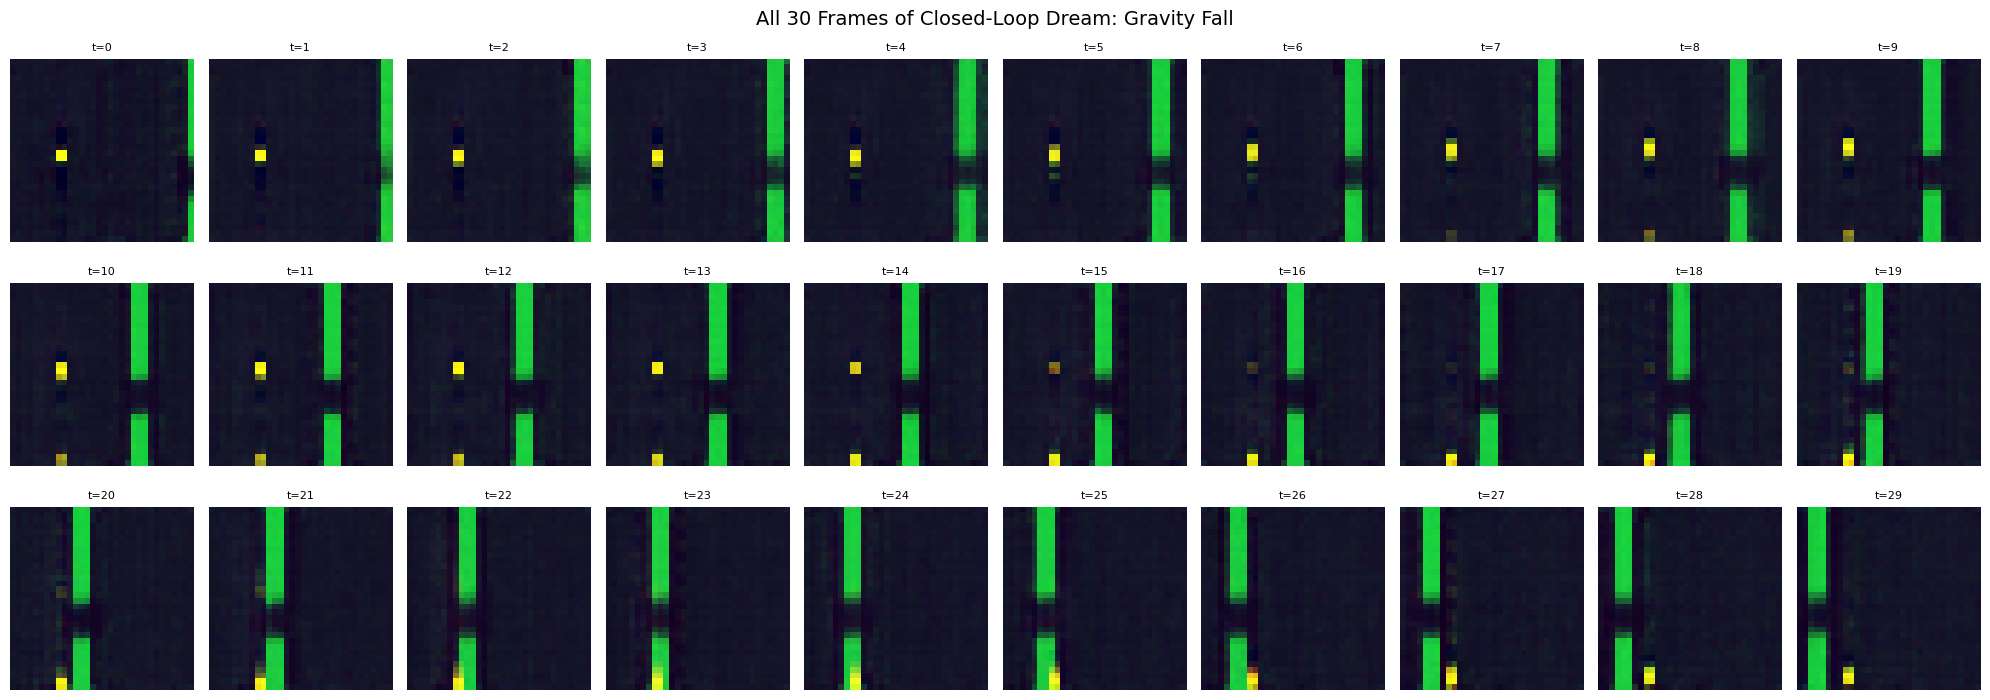

In [44]:
fig, axes = plt.subplots(3, 10, figsize=(20, 7))
axes = axes.flatten()

for t in range(30):
    axes[t].imshow(dreamed_frames[t])
    axes[t].set_title(f"t={t}", fontsize=8)
    axes[t].axis('off')

plt.tight_layout()
plt.suptitle("All 30 Frames of Closed-Loop Dream: Gravity Fall", y=1.02, fontsize=14)
plt.show()


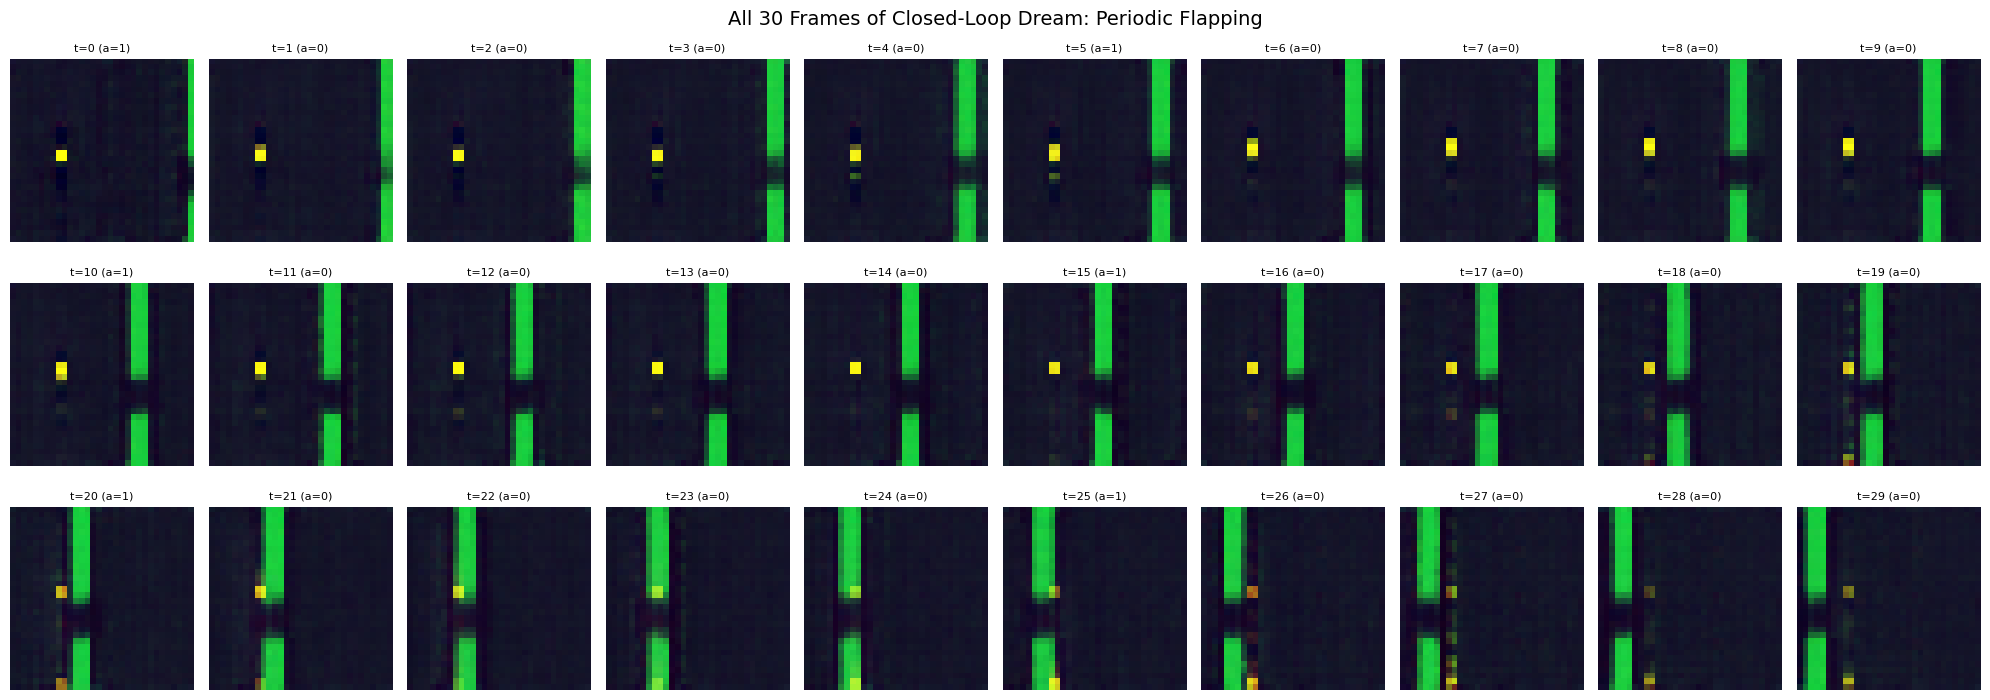

In [47]:
# 1. Action sequence: Flap (1) at t = 0, 5, 10, 15, 20, 25
actions_flapping = [1 if (t % 5 == 0) else 0 for t in range(30)]

# 2. Dream latents with memory model
dreamed_z_flap = dream_simulation(memory, initial_z, actions_flapping, device=device)

# 3. Decode dreamed latents into images
with torch.no_grad():
    dreamed_frames_flap = vae.decode(dreamed_z_flap).permute(0, 2, 3, 1).clamp(0, 1).cpu().numpy()

# 4. Plot all 30 frames
fig, axes = plt.subplots(3, 10, figsize=(20, 7))
axes = axes.flatten()

for t in range(30):
    axes[t].imshow(dreamed_frames_flap[t])
    axes[t].set_title(f"t={t} (a={actions_flapping[t]})", fontsize=8)
    axes[t].axis('off')

plt.tight_layout()
plt.suptitle("All 30 Frames of Closed-Loop Dream: Periodic Flapping", y=1.02, fontsize=14)
plt.show()


In [ ]:
# --- Step 4.3: Warm-Start Closed-Loop Simulation ---
# Warm up the GRU memory with 5 real frames so the network knows initial velocity & pipe speed
warmup_steps = 5
ep_latents = latent_dataset[0].to(device)
ep_actions = action_tensor[0].to(device)

h = None
with torch.no_grad():
    for t in range(warmup_steps):
        z_t = ep_latents[t].unsqueeze(0)
        a_t = ep_actions[t].unsqueeze(0)
        _, h = memory.step(z_t, a_t, h)

def dream_with_warmup(model, seed_z, initial_h, actions, device='cpu'):
    model.eval()
    with torch.no_grad():
        dreamed_latents = [seed_z.view(1, 32).to(device)]
        curr_z = seed_z.view(1, 32).to(device)
        h_state = initial_h
        
        for act in actions:
            a_t = torch.tensor([[act]], dtype=torch.float32, device=device)
            next_z, h_state = model.step(curr_z, a_t, h_state)
            dreamed_latents.append(next_z)
            curr_z = next_z
            
        return torch.cat(dreamed_latents, dim=0)

# Dream for 25 steps starting from t = 5
actions_flap_25 = [1 if (t % 5 == 0) else 0 for t in range(25)]
seed_z = ep_latents[warmup_steps]
dreamed_z_warm = dream_with_warmup(memory, seed_z, h, actions_flap_25, device=device)

with torch.no_grad():
    real_warmup_frames = vae.decode(ep_latents[:warmup_steps]).permute(0, 2, 3, 1).clamp(0, 1).cpu().numpy()
    dream_frames = vae.decode(dreamed_z_warm[1:]).permute(0, 2, 3, 1).clamp(0, 1).cpu().numpy()
    all_30_frames = np.concatenate([real_warmup_frames, dream_frames], axis=0)

# Plot all 30 frames
fig, axes = plt.subplots(3, 10, figsize=(20, 7))
axes = axes.flatten()

for t in range(30):
    axes[t].imshow(all_30_frames[t])
    phase = 'Real' if t < 5 else 'Dream'
    axes[t].set_title(f't={t} ({phase})', fontsize=8)
    axes[t].axis('off')

plt.tight_layout()
plt.suptitle('Warm-Start Dream (Real warmup t=0..4, Neural Dream t=5..29)', y=1.02, fontsize=14)
plt.show()


In [ ]:
# --- Save Trained Model Weights ---
torch.save(vae.state_dict(), 'vae_model.pth')
torch.save(memory.state_dict(), 'memory_model.pth')
print('Successfully saved vae_model.pth and memory_model.pth!')


## Project Milestone Summary: Mini Flappy Bird World Model
**Architecture:** Ha & Schmidhuber (World Models, 2018)

1. **Phase 1 (Environment & Rollouts):**
   - Built a lightweight 32x32 RGB Mini Flappy Bird environment.
   - Collected 200 random exploration episodes (20,000 frames total).

2. **Phase 2 (Vision Model - VAE):**
   - Built Conv2D Encoder -> 32-dimensional latent vector z -> ConvTranspose2D Decoder.
   - Trained with custom weighted MSE loss (15x weight on bird and pipe pixels) + KL divergence.
   - Encoded all 20,000 frames into a compact latent_dataset of shape (200, 100, 32).

3. **Phase 3 (Memory / Dynamics Model - M):**
   - Built Recurrent GRU (input [z_t, a_t] = 33 dims, hidden = 128 dims, output z_hat_next = 32 dims).
   - Trained over 20 epochs with MSE loss dropping by ~90% (0.310 -> 0.032).
   - Validated 1-step predictions side-by-side with ground-truth images.

4. **Phase 4 (Closed-Loop Dreaming / Simulation):**
   - Disconnected the game engine and ran pure autoregressive latent rollouts.
   - Verified realistic physical hallucinations for gravity drops, periodic flap impulses, and moving pipe gap navigation across 30-step filmstrips.
   - Demonstrated that warm-start memory (h) eliminates cold-start ambiguity and stabilizes long-horizon imagination.
